Exercise 1: Enzymatic Oxidation Batch Reactor
**Bioreactor Modelling and Simulation**

## Imports and Parameters

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# Parameters (from project statement)
k       = 3.2e-13   # m^(-3/2) h^(5/2)
N       = 30_000.0  # h^-1  (stirring rate)
CL_star = 6.0       # mg/L  (O2 saturation)
Vm      = 16.0      # g/L/h (max substrate consumption rate)
KS      = 7.0       # g/L   (substrate half-saturation constant)
KCL     = 0.3       # mg/L  (O2 half-saturation constant)
YOS     = 5.0       # mg_O2 / g_S
YPS     = 1.5       # g_P   / g_S

# Initial conditions
S0, CL0, P0 = 100.0, 6.0, 0.0

# Derived
kN3       = k * N**3
threshold = 3.0 * KCL  # O2 limitation threshold (mg/L)

print(f'k*N^3      = {kN3:.4f}')
print(f'threshold  = {threshold} mg/L')
print(f'kLa(G=30)  = {kN3*np.sqrt(30):.4f} h-1  (expected 47.32)')

k*N^3      = 8.6400
threshold  = 0.8999999999999999 mg/L
kLa(G=30)  = 47.3232 h-1  (expected 47.32)


## Helper Functions

In [2]:
def kLa_from_G(G):
    return kN3 * np.sqrt(G)

def odes(t, y, Vm_val, kLa):
    S, CL, P = y
    S  = max(S,  0.0)
    CL = max(CL, 0.0)
    rS = Vm_val * (S / (KS + S)) * (CL / (KCL + CL))
    return [-rS, kLa*(CL_star - CL) - YOS*rS, YPS*rS]

def run_batch(G, Vm_val=None, t_end=12.0):
    if Vm_val is None: Vm_val = Vm
    kLa = kLa_from_G(G)
    sol = solve_ivp(odes, [0, t_end], [S0, CL0, P0],
                    args=(Vm_val, kLa), method='RK45',
                    rtol=1e-9, atol=1e-9, max_step=0.005)
    return sol, kLa

def run_batch_kLa(kLa_val, Vm_val=None, t_end=12.0):
    if Vm_val is None: Vm_val = Vm
    return solve_ivp(odes, [0, t_end], [S0, CL0, P0],
                     args=(Vm_val, kLa_val), method='RK45',
                     rtol=1e-9, atol=1e-9, max_step=0.005)

def steady_state_time(sol, S_thresh=0.1):
    idx = np.where(sol.y[0] < S_thresh)[0]
    if len(idx) == 0: return None, None, None
    t_ss = sol.t[idx[0]]; P_ss = sol.y[2][idx[0]]
    return t_ss, P_ss, P_ss / t_ss

def rs_array(sol, Vm_val):
    S  = np.maximum(sol.y[0], 0)
    CL = np.maximum(sol.y[1], 0)
    return Vm_val * (S / (KS + S)) * (CL / (KCL + CL))

## Part a) — Simulation at G = 30 m3/h
Simulate the batch reactor and verify the system is not oxygen limited.

k_La    = 47.3232 h-1
min(CL) = 4.5209 mg/L  (threshold = 0.8999999999999999 mg/L)
Oxygen limited: False


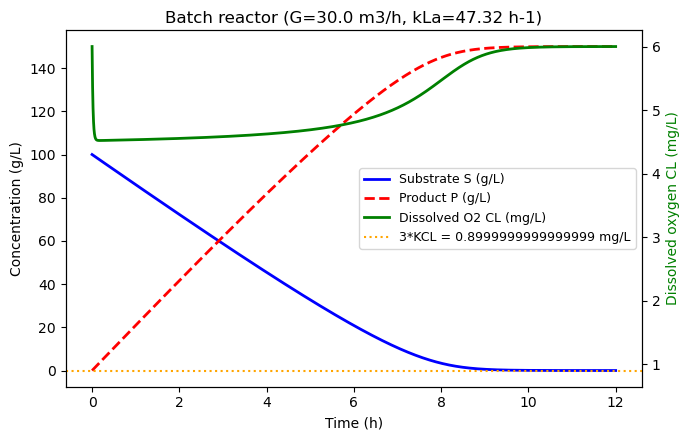

In [3]:
G_a = 30.0
sol_a, kLa_a = run_batch(G_a, t_end=12.0)
t_a, (S_a, CL_a, P_a) = sol_a.t, sol_a.y

print(f'k_La    = {kLa_a:.4f} h-1')
print(f'min(CL) = {CL_a.min():.4f} mg/L  (threshold = {threshold} mg/L)')
print(f'Oxygen limited: {CL_a.min() <= threshold}')

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()
ax1.plot(t_a, S_a,  'b-',  lw=2, label='Substrate S (g/L)')
ax1.plot(t_a, P_a,  'r--', lw=2, label='Product P (g/L)')
ax2.plot(t_a, CL_a, 'g-',  lw=2, label='Dissolved O2 CL (mg/L)')
ax2.axhline(threshold, color='orange', ls=':', lw=1.5, label=f'3*KCL = {threshold} mg/L')
ax1.set_xlabel('Time (h)'); ax1.set_ylabel('Concentration (g/L)')
ax2.set_ylabel('Dissolved oxygen CL (mg/L)', color='g')
ax1.set_title(f'Batch reactor (G={G_a} m3/h, kLa={kLa_a:.2f} h-1)')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=9)
plt.tight_layout()
plt.savefig('Ex_1_a.png', dpi=150)
plt.show()

## Part b) — Critical aeration rate G_crit
Find the aeration rate at which the system becomes oxygen limited using bisection.

G_crit  (numerical bisection) = 1.6090 m3/h
kLa_crit                      = 10.9594 h-1
G_crit  (analytical, appendix) = 1.8541 m3/h


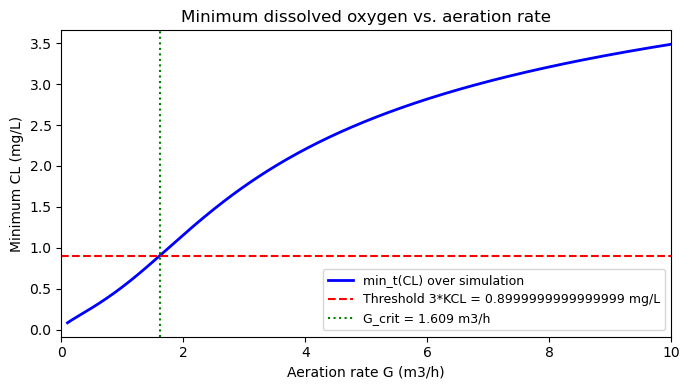

In [4]:
def min_CL_for_G(G):
    sol, _ = run_batch(G, t_end=15.0)
    return sol.y[1].min()

G_crit   = brentq(lambda G: min_CL_for_G(G) - threshold, 0.5, 5.0, xtol=1e-5)
kLa_crit = kLa_from_G(G_crit)

print(f'G_crit  (numerical bisection) = {G_crit:.4f} m3/h')
print(f'kLa_crit                      = {kLa_crit:.4f} h-1')
kLa_analytical = (YOS * Vm * 0.75) / (CL_star - threshold)
G_analytical   = (kLa_analytical / kN3) ** 2
print(f'G_crit  (analytical, appendix) = {G_analytical:.4f} m3/h')

G_scan     = np.linspace(0.1, 10, 400)
minCL_scan = [min_CL_for_G(G) for G in G_scan]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(G_scan, minCL_scan, 'b-', lw=2, label='min_t(CL) over simulation')
ax.axhline(threshold, color='r', ls='--', lw=1.5, label=f'Threshold 3*KCL = {threshold} mg/L')
ax.axvline(G_crit,    color='g', ls=':',  lw=1.5, label=f'G_crit = {G_crit:.3f} m3/h')
ax.set_xlabel('Aeration rate G (m3/h)'); ax.set_ylabel('Minimum CL (mg/L)')
ax.set_title('Minimum dissolved oxygen vs. aeration rate')
ax.legend(fontsize=9); ax.set_xlim(0, 10)
plt.tight_layout()
plt.savefig('Ex_1_b.png', dpi=150)
plt.show()

## Part c) — Effect of halving Vm at G_crit
Compare Vm = 16 and Vm = 8 g/L/h: does the average product formation rate halve?

Vm=16 g/L/h: t_ss=11.267 h, r_avg=13.3005 g/L/h, min(CL)=0.9000 mg/L, O2-limited=False
Vm=8 g/L/h: t_ss=20.103 h, r_avg=7.4541 g/L/h, min(CL)=2.9166 mg/L, O2-limited=False
Ratio r_avg(Vm/2)/r_avg(Vm) = 0.5604  (0.5 if perfectly halved)


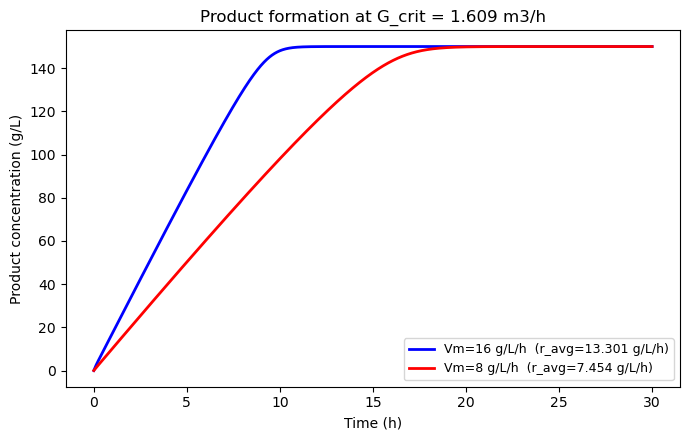

In [5]:
Vm_cases  = {'Vm=16 g/L/h': Vm, 'Vm=8 g/L/h': Vm/2}
colors_c  = ['b', 'r']
results_c = {}

for (label, Vm_val), col in zip(Vm_cases.items(), colors_c):
    sol, _ = run_batch(G_crit, Vm_val=Vm_val, t_end=30.0)
    t_ss, P_ss, r_avg = steady_state_time(sol)
    is_lim = sol.y[1].min() <= threshold
    results_c[label] = dict(sol=sol, r_avg=r_avg, t_ss=t_ss, P_ss=P_ss, is_lim=is_lim)
    print(f'{label}: t_ss={t_ss:.3f} h, r_avg={r_avg:.4f} g/L/h, '
          f'min(CL)={sol.y[1].min():.4f} mg/L, O2-limited={is_lim}')

r_full = results_c['Vm=16 g/L/h']['r_avg']
r_half = results_c['Vm=8 g/L/h']['r_avg']
print(f'Ratio r_avg(Vm/2)/r_avg(Vm) = {r_half/r_full:.4f}  (0.5 if perfectly halved)')

# Product plot -> Appendix figure
fig, ax = plt.subplots(figsize=(7, 4.5))
for (label, res), col in zip(results_c.items(), colors_c):
    ax.plot(res['sol'].t, res['sol'].y[2], color=col, lw=2,
            label=f'{label}  (r_avg={res["r_avg"]:.3f} g/L/h)')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Product concentration (g/L)')
ax.set_title(f'Product formation at G_crit = {G_crit:.3f} m3/h')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Ex_1_c_product.png', dpi=150)
plt.show()

## Part d) — Dissolved oxygen evolution for the two values of Vm

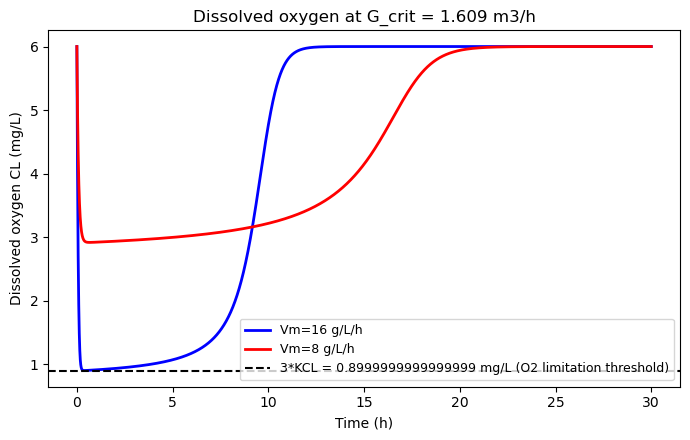

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for (label, res), col in zip(results_c.items(), colors_c):
    ax.plot(res['sol'].t, res['sol'].y[1], color=col, lw=2, label=label)
ax.axhline(threshold, color='k', ls='--', lw=1.5,
           label=f'3*KCL = {threshold} mg/L (O2 limitation threshold)')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Dissolved oxygen CL (mg/L)')
ax.set_title(f'Dissolved oxygen at G_crit = {G_crit:.3f} m3/h')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Ex_1_d.png', dpi=150)
plt.show()

## Part e) — Effect of reducing N by 15% at G_crit
Comment on the change of kLa, CL and rS.

Original N  = 30000 h-1  ->  kLa = 10.9594 h-1
N - 15%     = 25500 h-1  ->  kLa = 6.7304 h-1
Ratio kLa/kLa0 = 0.85^3 = 0.6141  (-38.6%)
min(CL) original = 0.9000 mg/L  O2-limited: False
min(CL) N-15%    = 0.3156 mg/L  O2-limited: True


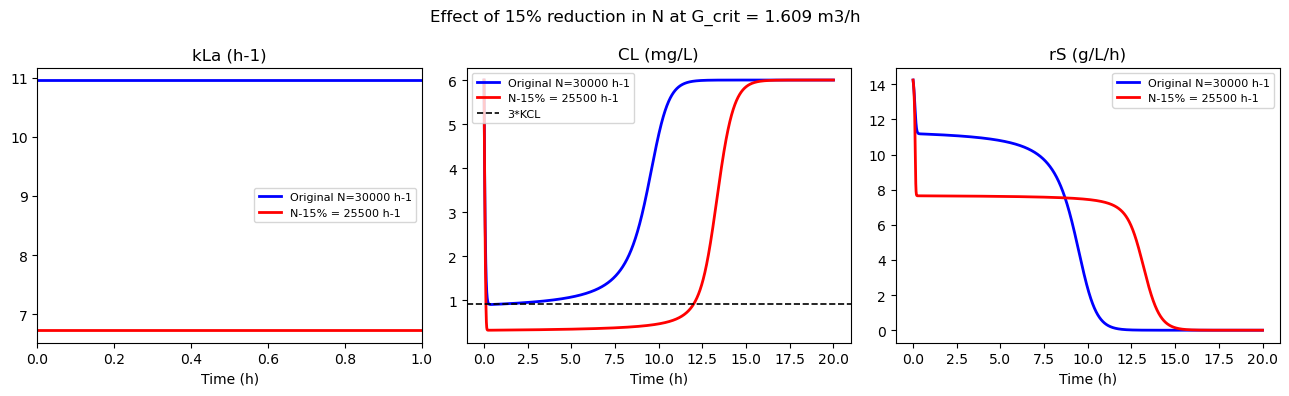

In [7]:
N_new   = N * 0.85
kLa_e0  = kLa_from_G(G_crit)
kLa_e1  = k * N_new**3 * np.sqrt(G_crit)

print(f'Original N  = {N:.0f} h-1  ->  kLa = {kLa_e0:.4f} h-1')
print(f'N - 15%     = {N_new:.0f} h-1  ->  kLa = {kLa_e1:.4f} h-1')
print(f'Ratio kLa/kLa0 = 0.85^3 = {0.85**3:.4f}  (-{(1-0.85**3)*100:.1f}%)')

sol_e0 = run_batch_kLa(kLa_e0, t_end=20.0)
sol_e1 = run_batch_kLa(kLa_e1, t_end=20.0)
rs_e0  = rs_array(sol_e0, Vm)
rs_e1  = rs_array(sol_e1, Vm)

print(f'min(CL) original = {sol_e0.y[1].min():.4f} mg/L  '
      f'O2-limited: {sol_e0.y[1].min() < threshold}')
print(f'min(CL) N-15%    = {sol_e1.y[1].min():.4f} mg/L  '
      f'O2-limited: {sol_e1.y[1].min() < threshold}')

# 3-panel figure -> Appendix
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [(sol_e0, rs_e0, kLa_e0, f'Original N={N:.0f} h-1', 'b'),
         (sol_e1, rs_e1, kLa_e1, f'N-15% = {N_new:.0f} h-1', 'r')]
for sol, rs, kLa_val, lbl, col in pairs:
    axes[0].axhline(kLa_val, color=col, lw=2, label=lbl)
    axes[1].plot(sol.t, sol.y[1], color=col, lw=2, label=lbl)
    axes[2].plot(sol.t, rs,       color=col, lw=2, label=lbl)
axes[1].axhline(threshold, color='k', ls='--', lw=1.2, label='3*KCL')
for ax, title in zip(axes, ['kLa (h-1)', 'CL (mg/L)', 'rS (g/L/h)']):
    ax.set_xlabel('Time (h)'); ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle(f'Effect of 15% reduction in N at G_crit = {G_crit:.3f} m3/h')
plt.tight_layout()
plt.savefig('Ex_1_e.png', dpi=150)
plt.show()

## Part f) — Five (N, G) combinations for non-oxygen-limited operation

Case                          kLa (h-1)  min(CL)  r_avg    Lim?
-----------------------------------------------------------------
Case 1: G x2, N unchanged         15.50    1.861   14.453   False
Case 2: G x5, N unchanged         24.51    3.217   14.986   False
Case 3: N x1.10, G unchanged      14.59    1.671   14.318   False
Case 4: N x1.20, G unchanged      18.94    2.489   14.761   False
Case 5: N x1.10, G x1.5           17.87    2.309   14.691   False


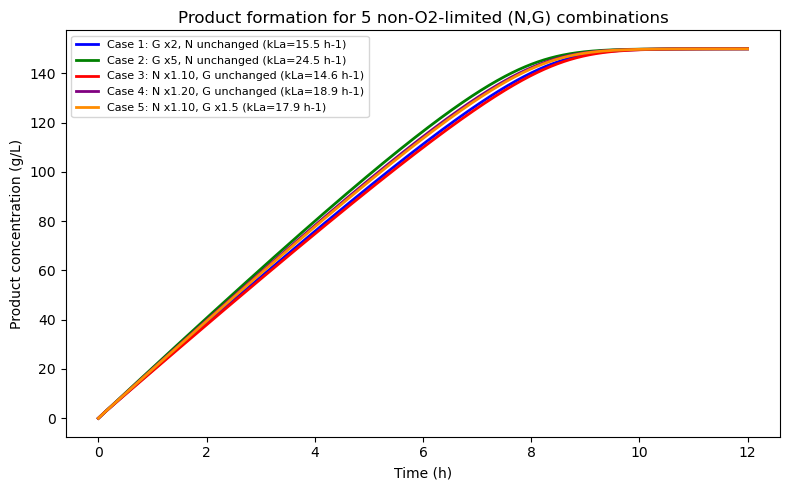

In [8]:
combos_f = [
    ('Case 1: G x2, N unchanged',      N,        G_crit * 2.0),
    ('Case 2: G x5, N unchanged',      N,        G_crit * 5.0),
    ('Case 3: N x1.10, G unchanged',   N * 1.10, G_crit),
    ('Case 4: N x1.20, G unchanged',   N * 1.20, G_crit),
    ('Case 5: N x1.10, G x1.5',        N * 1.10, G_crit * 1.5),
]
colors_f = ['blue', 'green', 'red', 'purple', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 5))
print(f'Case                          kLa (h-1)  min(CL)  r_avg    Lim?')
print('-' * 65)
for (label, N_f, G_f), col in zip(combos_f, colors_f):
    kLa_f = k * N_f**3 * np.sqrt(G_f)
    sol   = solve_ivp(odes, [0, 12], [S0, CL0, P0],
                      args=(Vm, kLa_f), method='RK45',
                      rtol=1e-9, atol=1e-9, max_step=0.005)
    minCL = sol.y[1].min()
    t_ss, P_ss, r_avg = steady_state_time(sol)
    print(f'{label:<30} {kLa_f:>8.2f}   {minCL:>6.3f}   {r_avg:>6.3f}   {minCL<=threshold}')
    ax.plot(sol.t, sol.y[2], color=col, lw=2,
            label=f'{label} (kLa={kLa_f:.1f} h-1)')

ax.set_xlabel('Time (h)'); ax.set_ylabel('Product concentration (g/L)')
ax.set_title('Product formation for 5 non-O2-limited (N,G) combinations')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('Ex_1_f.png', dpi=150)
plt.show()